# 📊   Análisis de Gastos ETES 2025 - MEF
#
Gasto Presupuestal de las Entidades de Tratamiento Empresarial - ETES del año 2025
#
---
## **GRUPO 2 - INTEGRANTES:**
   ### •	CHONATI VARGAS JONATHAN CHRISS 
   ### •	GARCÍA PÉREZ JESÚS AUGUSTO 
   ### •	GUERRERO CEVALLOS JUAN CARLOS 
   ### •	NEYRA PAREDES KELLY LALESKA
---
#
### Análisis Descriptivo y Predictivo del Presupuesto de Empresas de Saneamiento

**Dataset:** `2025-Gastos-ETES.xlsx` · 78,588 registros · 70 ejecutoras · 25 departamentos

---
**Contenido del notebook:**
| # | Sección |
|---|---------|
| 1 | Instalación de dependencias |
| 2 | Importaciones y configuración |
| 3 | Carga y diagnóstico de problemas |
| 4 | Estadísticos descriptivos |
| 5 | Gráfico 1 — Ejecución mensual |
| 6 | Gráfico 2 — Distribución por categoría |
| 7 | Gráfico 3 — Top 10 ejecutoras |
| 8 | Gráfico 4 — Heatmap por departamento |
| 9 | Gráfico 5 — Boxplot por genérica |
| 10 | Modelo predictivo (regresión polinómica) |
| 11 | Gráfico 6 — Tendencia real vs modelo |
| 12 | 🔮 Predicción interactiva (widgets) |

## Celda 1 — Instalación de dependencias
> Ejecuta esta celda **una sola vez** antes de continuar.

In [1]:
import sys
!{sys.executable} -m pip install pandas openpyxl matplotlib seaborn numpy scikit-learn ipywidgets --quiet
print("✓ Dependencias instaladas.")

✓ Dependencias instaladas.


## Celda 2 — Importaciones y configuración de estilo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import ipywidgets as widgets
from IPython.display import display, HTML
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f9fa",
    "axes.edgecolor":   "#dee2e6",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

print("✓ Librerías importadas correctamente.")

✓ Librerías importadas correctamente.


## Celda 3 — Carga del dataset y diagnóstico de problemas
> ⚠️ Asegúrate de que `2025-Gastos-ETES.xlsx` esté en la **misma carpeta** que este notebook.

In [3]:
RUTA = "2025-Gastos-ETES.xlsx"   # ← cambia la ruta si es necesario

df_raw = pd.read_excel(RUTA, header=0)
print(f"Dataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")

# ── Diagnóstico de problemas ──
registros_mes0 = (df_raw["MES_EJE"] == 0).sum()
registros_neg  = (df_raw["MONTO_EJECUCION"] < 0).sum()
pia_cero       = (df_raw["MONTO_PIA"] == 0).sum()
pim_cero       = (df_raw["MONTO_PIM"] == 0).sum()
valores_nulos  = df_raw.isnull().sum().sum()

print("\n" + "="*55)
print("  ⚠  PROBLEMAS DETECTADOS EN EL DATASET")
print("="*55)
print(f"  • Registros con MES_EJE = 0   : {registros_mes0:>8,}  ({registros_mes0/len(df_raw)*100:.1f}%)")
print(f"  • MONTO_EJECUCION negativo    : {registros_neg:>8,}")
print(f"  • MONTO_PIA = 0 (sin presup.) : {pia_cero:>8,}")
print(f"  • MONTO_PIM = 0 (sin presup.) : {pim_cero:>8,}")
print(f"  • Valores nulos totales       : {valores_nulos:>8,}")
print("="*55)

# ── Dataset limpio ──
df = df_raw[df_raw["MES_EJE"] > 0].copy()
print(f"\n✓ Dataset limpio (MES_EJE > 0): {len(df):,} registros")

Dataset cargado: 78,588 filas × 51 columnas

  ⚠  PROBLEMAS DETECTADOS EN EL DATASET
  • Registros con MES_EJE = 0   :   14,657  (18.7%)
  • MONTO_EJECUCION negativo    :      570
  • MONTO_PIA = 0 (sin presup.) :   67,202
  • MONTO_PIM = 0 (sin presup.) :   64,464
  • Valores nulos totales       :        0

✓ Dataset limpio (MES_EJE > 0): 63,931 registros


## Celda 4 — Estadísticos descriptivos

In [4]:
print("\n" + "="*55)
print("  ESTADÍSTICOS DESCRIPTIVOS — MONTO_EJECUCION")
print("="*55)
stats = df["MONTO_EJECUCION"].describe().rename({
    "Cantidad":"Registros","Promedio":"Media","std":"Desv. estándar",
    "min":"Mínimo","25%":"Percentil 25","50%":"Mediana",
    "75%":"Percentil 75","max":"Máximo"
})
for k, v in stats.items():
    print(f"  {k:<20}: S/ {v:>15,.2f}")

print(f"\n  Ejecutoras únicas     : {df['EJECUTORA_NOMBRE'].nunique()}")
print(f"  Departamentos únicos  : {df['DEPARTAMENTO_EJECUTORA_NOMBRE'].nunique()}")
print(f"  Total ejecutado       : S/ {df['MONTO_EJECUCION'].sum()/1e6:,.2f} M")

# Vista previa del DataFrame
df.head(3)


  ESTADÍSTICOS DESCRIPTIVOS — MONTO_EJECUCION
  count               : S/       63,931.00
  mean                : S/       29,163.80
  Desv. estándar      : S/      173,538.15
  Mínimo              : S/   -3,368,050.00
  Percentil 25        : S/          796.79
  Mediana             : S/        3,559.00
  Percentil 75        : S/       15,318.00
  Máximo              : S/   27,386,971.00

  Ejecutoras únicas     : 70
  Departamentos únicos  : 25
  Total ejecutado       : S/ 1,864.47 M


,ANO_EJE,MES_EJE,GRUPO_ENTIDAD,GRUPO_ENTIDAD_NOMBRE,SEC_EJEC,EJECUTORA,EJECUTORA_NOMBRE,DEPARTAMENTO_EJECUTORA,DEPARTAMENTO_EJECUTORA_NOMBRE,PROVINCIA_EJECUTORA,...,SUBGENERICA_NOMBRE,SUBGENERICA_DET,SUBGENERICA_DET_NOMBRE,ESPECIFICA,ESPECIFICA_NOMBRE,ESPECIFICA_DET,ESPECIFICA_DET_NOMBRE,MONTO_PIA,MONTO_PIM,MONTO_EJECUCION
0,2025,5,5,EMPRESAS MUNICIPALES DE AGUA POTABLE Y ALCANTA...,500160,0,EMPRESA PRESTADORA MUNICIPAL DE SERVICIO DE AG...,1,AMAZONAS,1,...,CONTRATACION DE SERVICIOS,3,"SERVICIOS DE LIMPIEZA, SEGURIDAD Y VIGILANCIA",1,"SERVICIOS DE LIMPIEZA, SEGURIDAD Y VIGILANCIA",2,SERVICIOS DE SEGURIDAD Y VIGILANCIA,0,0,6500.0
1,2025,8,5,EMPRESAS MUNICIPALES DE AGUA POTABLE Y ALCANTA...,500160,0,EMPRESA PRESTADORA MUNICIPAL DE SERVICIO DE AG...,1,AMAZONAS,1,...,CONTRATACION DE SERVICIOS,4,"SERVICIO DE MANTENIMIENTO, ACONDICIONAMIENTO Y...",7,DE MAQUINARIAS Y EQUIPOS,1,DE MAQUINARIAS Y EQUIPOS,0,0,23940.0
2,2025,9,5,EMPRESAS MUNICIPALES DE AGUA POTABLE Y ALCANTA...,500160,0,EMPRESA PRESTADORA MUNICIPAL DE SERVICIO DE AG...,1,AMAZONAS,1,...,"ADQUISICION DE VEHICULOS, MAQUINARIAS Y OTROS",2,"ADQUISICION DE MAQUINARIAS, EQUIPO Y MOBILIARIO",9,ADQUISICION DE MAQUINARIA Y EQUIPO DIVERSOS,99,"MAQUINARIAS, EQUIPOS Y MOBILIARIOS DE OTRAS IN...",0,0,480.0


## Celda 5 — Gráfico 1: Ejecución mensual

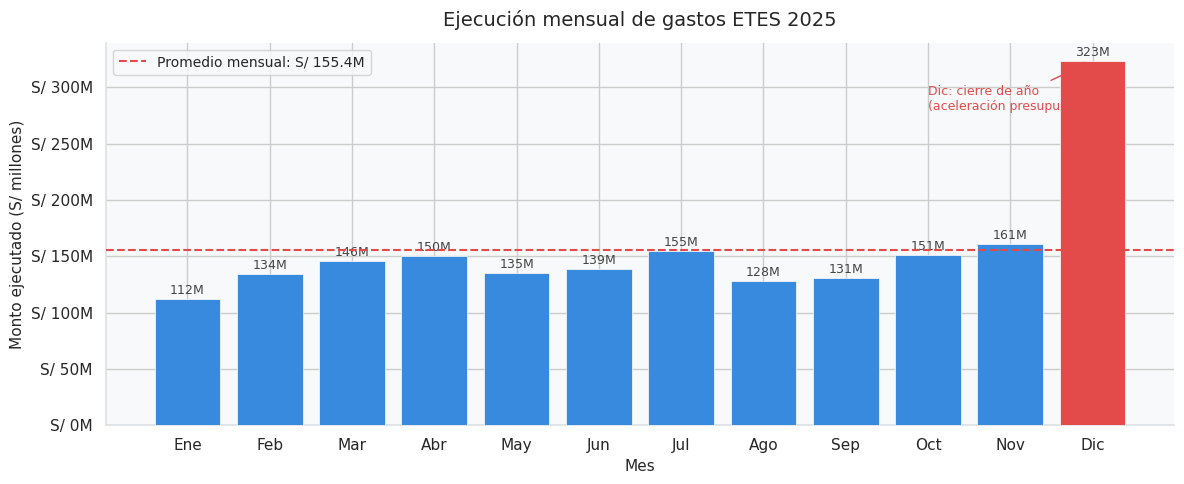

✓ Guardado: grafico1_ejecucion_mensual.png


In [5]:
meses_label = ["Ene","Feb","Mar","Abr","May","Jun",
                "Jul","Ago","Sep","Oct","Nov","Dic"]

monthly = (df.groupby("MES_EJE")["MONTO_EJECUCION"]
             .sum()
             .reset_index()
             .rename(columns={"MONTO_EJECUCION": "total"}))
monthly["total_M"]    = monthly["total"] / 1e6
monthly["mes_nombre"] = monthly["MES_EJE"].apply(lambda x: meses_label[x-1])
promedio_M = monthly["total_M"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
colores = ["#E24B4A" if m == 12 else "#378ADD" for m in monthly["MES_EJE"]]
bars = ax.bar(monthly["mes_nombre"], monthly["total_M"],
              color=colores, edgecolor="white", linewidth=0.5, zorder=3)
ax.axhline(promedio_M, color="#E24B4A", linestyle="--", linewidth=1.5,
           label=f"Promedio mensual: S/ {promedio_M:.1f}M", zorder=4)
for bar, val in zip(bars, monthly["total_M"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{val:.0f}M", ha="center", va="bottom", fontsize=9,
            color="#444", fontweight="500")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"S/ {x:.0f}M"))
ax.set_title("Ejecución mensual de gastos ETES 2025", fontsize=14, pad=12)
ax.set_xlabel("Mes")
ax.set_ylabel("Monto ejecutado (S/ millones)")
ax.legend(fontsize=10)
ax.annotate("Dic: cierre de año\n(aceleración presupuestal)",
            xy=(11, monthly.loc[monthly["MES_EJE"]==12,"total_M"].values[0]),
            xytext=(9, 280), fontsize=9, color="#E24B4A",
            arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1))
plt.tight_layout()
plt.savefig("grafico1_ejecucion_mensual.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico1_ejecucion_mensual.png")

## Celda 6 — Gráfico 2: Distribución por categoría de gasto

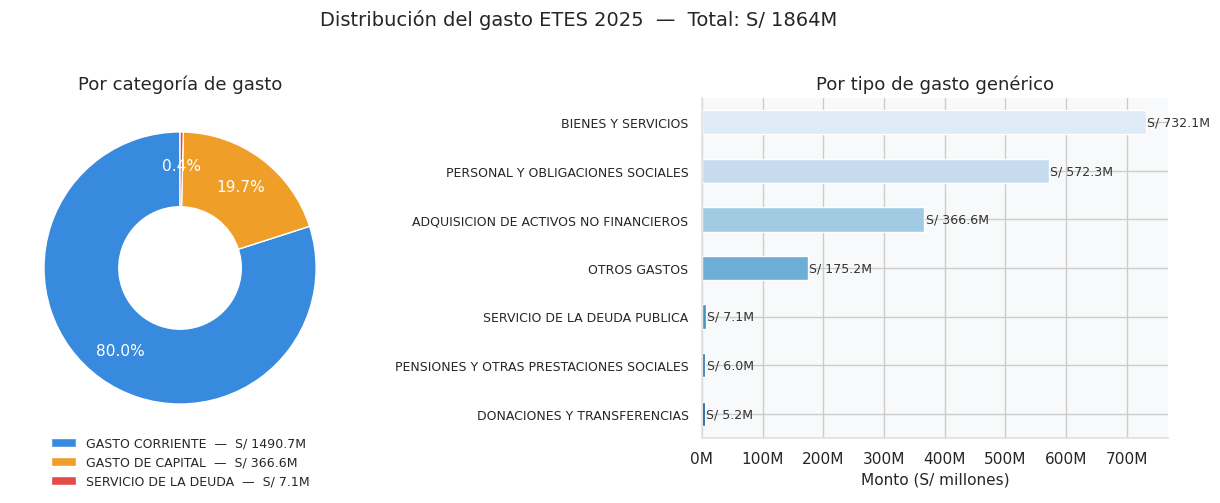

✓ Guardado: grafico2_distribucion_gasto.png


In [6]:
cat_gasto = (df.groupby("CATEGORIA_GASTO_NOMBRE")["MONTO_EJECUCION"]
               .sum().sort_values(ascending=False))
cat_M   = cat_gasto / 1e6
total_M = cat_M.sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Donut
colores_cat = ["#378ADD", "#EF9F27", "#E24B4A"]
wedges, texts, autotexts = axes[0].pie(
    cat_M.values, labels=None,
    autopct=lambda p: f"{p:.1f}%", colors=colores_cat,
    startangle=90, wedgeprops=dict(width=0.55, edgecolor="white"), pctdistance=0.75)
for at in autotexts:
    at.set(fontsize=11, fontweight="500", color="white")
axes[0].set_title("Por categoría de gasto", fontsize=13)
legend_labels = [f"{n}  —  S/ {v:.1f}M" for n, v in zip(cat_M.index, cat_M.values)]
axes[0].legend(wedges, legend_labels, loc="lower center",
               bbox_to_anchor=(0.5, -0.18), fontsize=9, frameon=False)

# Barras por genérica
generica = (df.groupby("GENERICA_NOMBRE")["MONTO_EJECUCION"].sum().sort_values() / 1e6)
palette_gen = sns.color_palette("Blues_r", len(generica))
generica.plot(kind="barh", ax=axes[1], color=palette_gen, edgecolor="white")
for i, v in enumerate(generica.values):
    axes[1].text(v + 2, i, f"S/ {v:.1f}M", va="center", fontsize=9, color="#333")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
axes[1].set_title("Por tipo de gasto genérico", fontsize=13)
axes[1].set_xlabel("Monto (S/ millones)")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", labelsize=9)

plt.suptitle(f"Distribución del gasto ETES 2025  —  Total: S/ {total_M:.0f}M",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("grafico2_distribucion_gasto.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico2_distribucion_gasto.png")

## Celda 7 — Gráfico 3: Top 10 ejecutoras

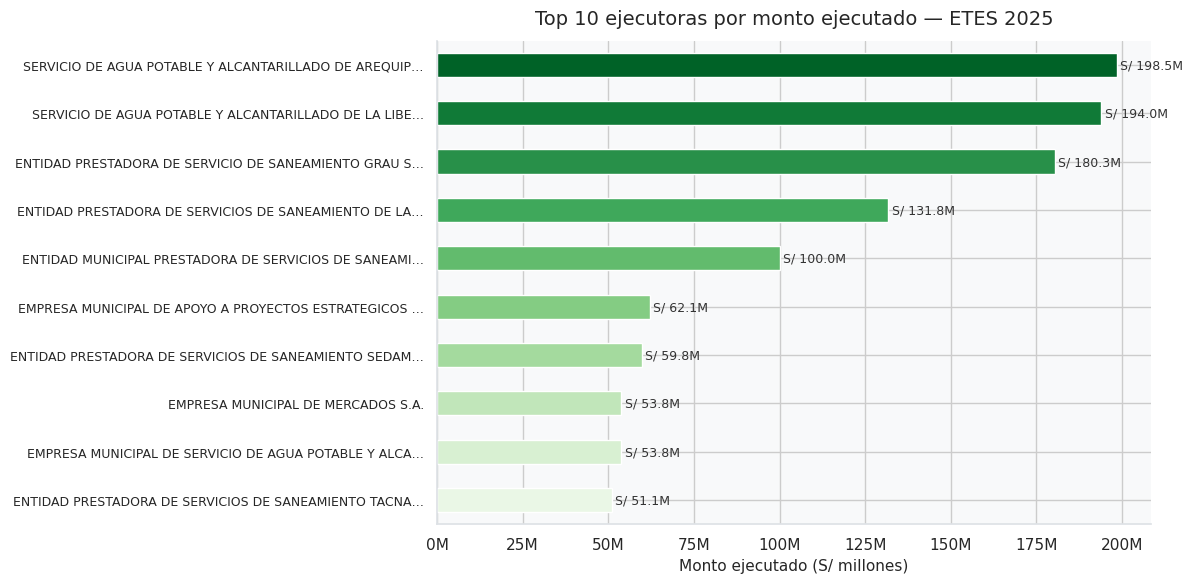

✓ Guardado: grafico3_top10_ejecutoras.png


In [7]:
def abreviar(nombre, max_len=52):
    return nombre[:max_len] + "…" if len(nombre) > max_len else nombre

top10 = (df.groupby("EJECUTORA_NOMBRE")["MONTO_EJECUCION"]
           .sum().nlargest(10).sort_values() / 1e6)
top10.index = [abreviar(n) for n in top10.index]

fig, ax = plt.subplots(figsize=(12, 6))
palette_top = sns.color_palette("Greens", len(top10))
top10.plot(kind="barh", ax=ax, color=palette_top, edgecolor="white")
for i, v in enumerate(top10.values):
    ax.text(v + 1, i, f"S/ {v:.1f}M", va="center", fontsize=9, color="#333")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
ax.set_title("Top 10 ejecutoras por monto ejecutado — ETES 2025", fontsize=14, pad=12)
ax.set_xlabel("Monto ejecutado (S/ millones)")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.savefig("grafico3_top10_ejecutoras.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico3_top10_ejecutoras.png")

## Celda 8 — Gráfico 4: Mapa de Calor de ejecución por departamento

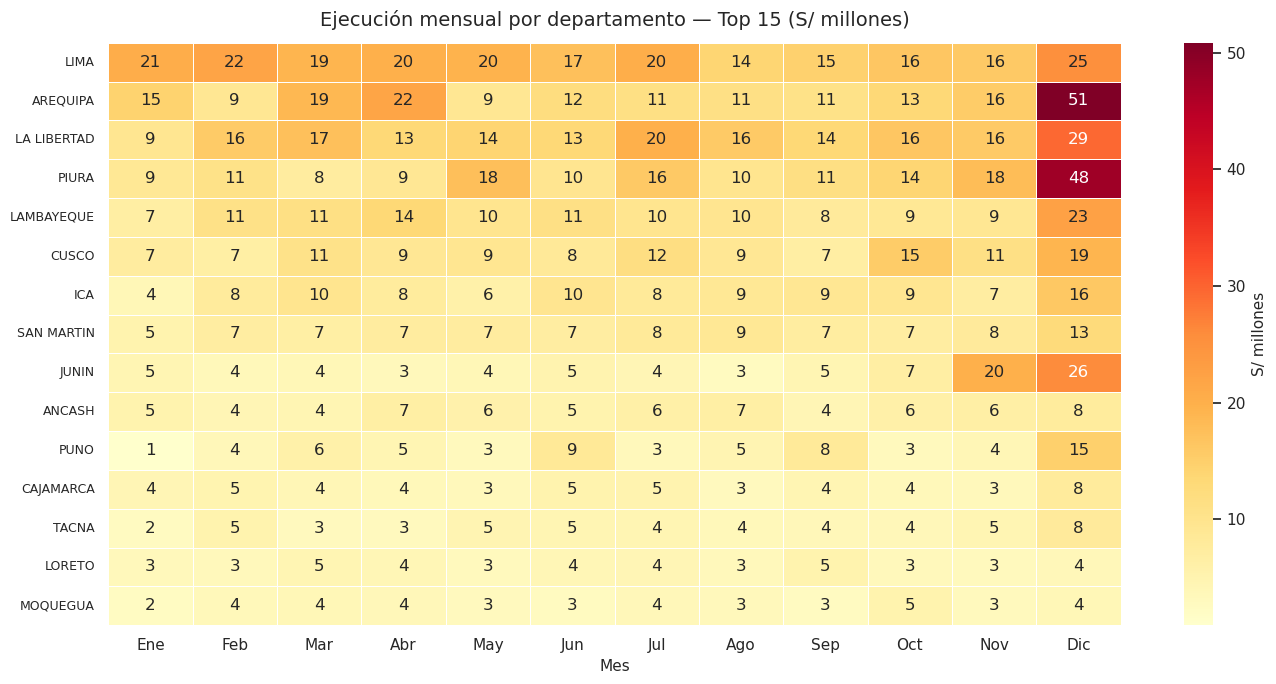

✓ Guardado: grafico4_mapadecalor_departamentos.png


In [8]:
dept_mes = (df.groupby(["DEPARTAMENTO_EJECUTORA_NOMBRE", "MES_EJE"])["MONTO_EJECUCION"]
              .sum().reset_index()
              .pivot(index="DEPARTAMENTO_EJECUTORA_NOMBRE",
                     columns="MES_EJE", values="MONTO_EJECUCION")
              .fillna(0) / 1e6)
dept_mes.columns = meses_label
dept_mes["_total"] = dept_mes.sum(axis=1)
dept_mes = dept_mes.sort_values("_total", ascending=False).head(15).drop(columns="_total")

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(dept_mes, ax=ax, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.5, linecolor="white", cbar_kws={"label": "S/ millones"})
ax.set_title("Ejecución mensual por departamento — Top 15 (S/ millones)", fontsize=14, pad=12)
ax.set_xlabel("Mes")
ax.set_ylabel("")
ax.tick_params(axis="y", rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig("grafico4_mapadecalor_departamentos.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico4_mapadecalor_departamentos.png")

## Celda 9 — Gráfico 5: Diagrama de Caja (Boxplot) por tipo de gasto genérico

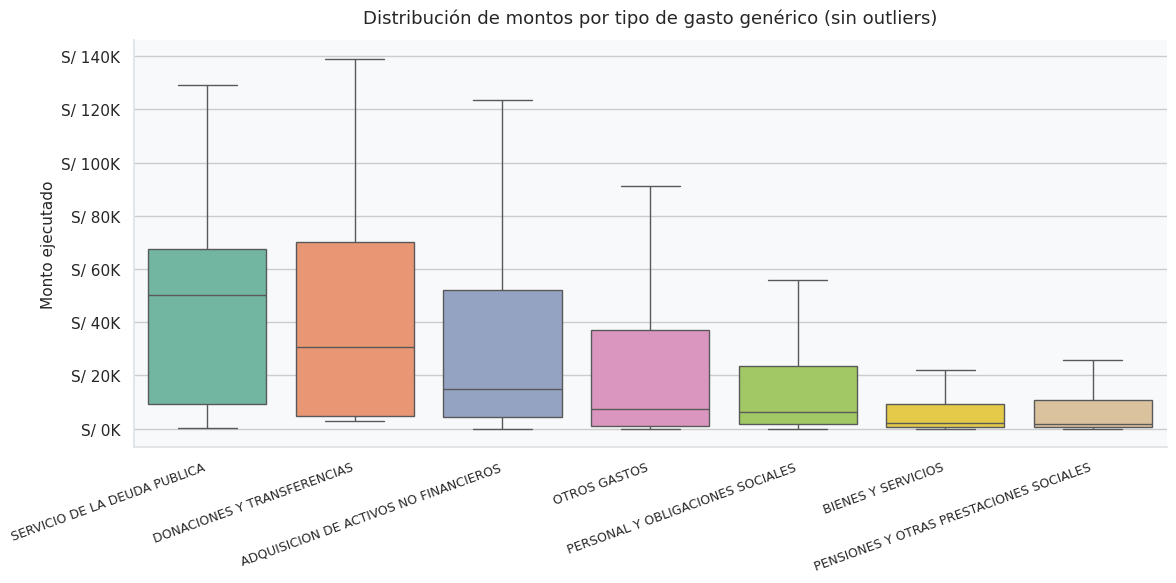

✓ Guardado: grafico5_boxplot_generica.png


In [9]:
orden = (df.groupby("GENERICA_NOMBRE")["MONTO_EJECUCION"]
           .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df[df["MONTO_EJECUCION"] > 0],
            x="GENERICA_NOMBRE", y="MONTO_EJECUCION",
            order=orden, palette="Set2", showfliers=False, ax=ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"S/ {x/1e3:.0f}K"))
ax.set_title("Distribución de montos por tipo de gasto genérico (sin outliers)",
             fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Monto ejecutado")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("grafico5_boxplot_generica.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico5_boxplot_generica.png")

## Celda 10 — Modelo predictivo: Regresión polinómica grado 2

El modelo usa los **12 meses** de ejecución agregada para ajustar una curva polinómica de grado 2 (parábola).  
Luego aplica los **pesos históricos por tipo de gasto** para desagregar la predicción.

In [10]:
print("="*55)
print("  MODELO PREDICTIVO — Regresión polinómica (grado 2)")
print("="*55)

monthly_model = (df.groupby("MES_EJE")["MONTO_EJECUCION"]
                   .sum().reset_index()
                   .rename(columns={"MONTO_EJECUCION": "total"}))
monthly_model["total_M"] = monthly_model["total"] / 1e6

X_raw  = monthly_model["MES_EJE"].values.reshape(-1, 1)
y      = monthly_model["total_M"].values

poly   = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(X_raw)
modelo = LinearRegression()
modelo.fit(X_poly, y)

y_pred = modelo.predict(X_poly)
r2     = r2_score(y, y_pred)
mae    = mean_absolute_error(y, y_pred)

print(f"\n  Coeficientes  : {[round(c,4) for c in modelo.coef_]}")
print(f"  Intercepto    : {modelo.intercept_:.4f}")
print(f"  R² (ajuste)   : {r2:.4f}")
print(f"  MAE           : S/ {mae:.2f}M")
print(f"\n  El modelo explica el {r2*100:.1f}% de la varianza mensual.")
print("  El pico de diciembre (cierre presupuestal) domina la curva.")

  MODELO PREDICTIVO — Regresión polinómica (grado 2)

  Coeficientes  : [np.float64(0.0), np.float64(-20.2873), np.float64(2.2342)]
  Intercepto    : 166.2210
  R² (ajuste)   : 0.5370
  MAE           : S/ 29.65M

  El modelo explica el 53.7% de la varianza mensual.
  El pico de diciembre (cierre presupuestal) domina la curva.


## Celda 11 — Gráfico 6: Tendencia real vs curva del modelo

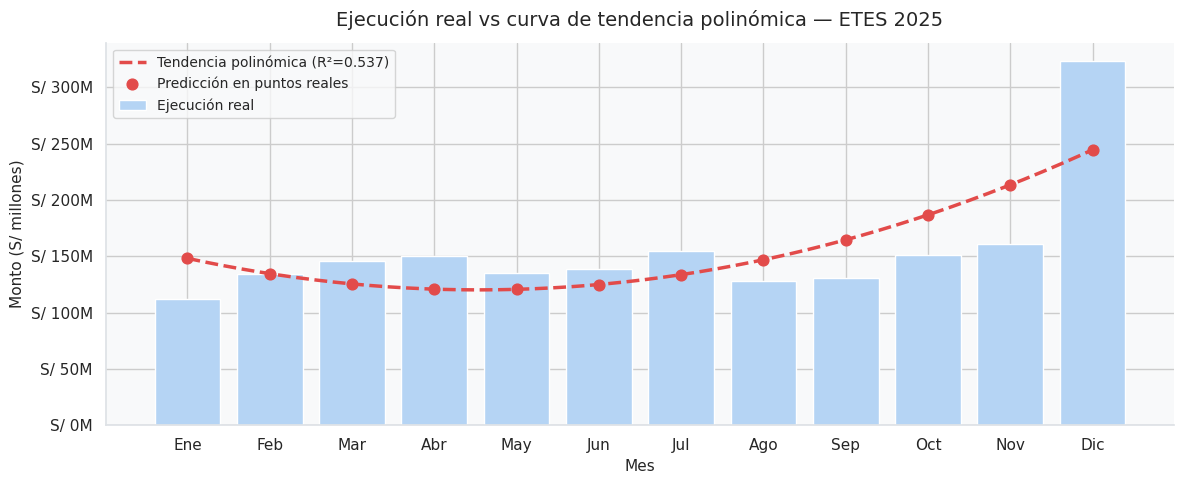

✓ Guardado: grafico6_tendencia_modelo.png


In [11]:
x_cont = np.linspace(1, 12, 200).reshape(-1, 1)
y_cont = modelo.predict(poly.transform(x_cont))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_model["MES_EJE"], monthly_model["total_M"],
       color="#B5D4F4", edgecolor="white", label="Ejecución real", zorder=2)
ax.plot(x_cont, y_cont, color="#E24B4A", linewidth=2.5, linestyle="--",
        label=f"Tendencia polinómica (R²={r2:.3f})", zorder=3)
ax.scatter(monthly_model["MES_EJE"], y_pred, color="#E24B4A",
           s=60, zorder=4, label="Predicción en puntos reales")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"S/ {x:.0f}M"))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_label)
ax.set_title("Ejecución real vs curva de tendencia polinómica — ETES 2025",
             fontsize=14, pad=12)
ax.set_xlabel("Mes")
ax.set_ylabel("Monto (S/ millones)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("grafico6_tendencia_modelo.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico6_tendencia_modelo.png")

## Celda 12 — 🔮 Predicción interactiva

Selecciona el **mes** y el **tipo de gasto genérico**, luego presiona el botón para calcular la ejecución estimada.

In [13]:
generica_pesos = {
    "Bienes y Servicios":                    0.393,
    "Personal y Obligaciones Sociales":       0.307,
    "Adquisición de Activos No Financieros":  0.197,
    "Otros Gastos":                           0.094,
    "Servicio de la Deuda Pública":           0.004,
    "Pensiones y Prestaciones Sociales":      0.003,
    "Donaciones y Transferencias":            0.003,
}

def predecir_ejecucion(mes, tipo_gasto):
    X_input      = poly.transform([[mes]])
    pred_total_M = modelo.predict(X_input)[0]
    peso         = generica_pesos[tipo_gasto]
    pred_S       = pred_total_M * peso * 1e6
    prom_S       = monthly_model["total_M"].mean() * peso * 1e6
    var_pct      = (pred_S - prom_S) / prom_S * 100

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Izquierdo: curva con punto destacado
    axes[0].plot(x_cont, y_cont * peso * 1e6, color="#378ADD", linewidth=2, label="Tendencia")
    axes[0].scatter(monthly_model["MES_EJE"], monthly_model["total_M"] * peso * 1e6,
                    color="#B5D4F4", s=50, zorder=3, label="Datos reales")
    axes[0].scatter([mes], [pred_total_M * peso * 1e6], color="#E24B4A",
                    s=140, zorder=5, label=f"Predicción mes {mes}")
    axes[0].axhline(prom_S, color="#EF9F27", linestyle=":", linewidth=1.5,
                    label=f"Promedio: S/ {prom_S/1e6:.2f}M")
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"S/ {x/1e6:.1f}M"))
    axes[0].set_xticks(range(1, 13))
    axes[0].set_xticklabels(meses_label, fontsize=8)
    axes[0].set_title(f"{tipo_gasto}\nPredicción mensual", fontsize=11)
    axes[0].legend(fontsize=8)
    axes[0].set_xlabel("Mes")
    axes[0].set_ylabel("Monto")

    # Derecho: comparativa predicción vs promedio
    valores    = [pred_S / 1e6, prom_S / 1e6]
    categorias = ["Predicción", "Promedio histórico"]
    colores_b  = ["#E24B4A" if pred_S >= prom_S else "#378ADD", "#B5D4F4"]
    bars2 = axes[1].bar(categorias, valores, color=colores_b, edgecolor="white", width=0.4)
    for bar, val in zip(bars2, valores):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + max(valores)*0.02,
                     f"S/ {val:.2f}M", ha="center", fontsize=11, fontweight="500")
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"S/ {x:.1f}M"))
    signo = "+" if var_pct >= 0 else ""
    axes[1].set_title(
        f"Mes: {meses_label[mes-1]}  |  Variación vs promedio: {signo}{var_pct:.1f}%",
        fontsize=11)
    axes[1].set_ylabel("S/ millones")

    plt.suptitle(f"PREDICCIÓN — {tipo_gasto.upper()}", fontsize=13, fontweight="500", y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\n  ┌──────────────────────────────────────────────────┐")
    print(f"  │  Mes               : {meses_label[mes-1]:<29}│")
    print(f"  │  Tipo de gasto     : {tipo_gasto[:29]:<29}│")
    print(f"  │  Predicción        : S/ {pred_S:>12,.2f}               │")
    print(f"  │  Promedio histórico: S/ {prom_S:>12,.2f}               │")
    print(f"  │  Variación         : {signo}{var_pct:.1f}%{'':<27}│")
    print(f"  └──────────────────────────────────────────────────┘")

# ── Widgets ──
w_mes = widgets.IntSlider(
    value=6, min=1, max=12, step=1, description="Mes:",
    style={"description_width": "60px"},
    layout=widgets.Layout(width="420px"), continuous_update=False)
w_mes_etq = widgets.Label(value="  Ene  Feb  Mar  Abr  May  Jun  Jul  Ago  Sep  Oct  Nov  Dic")
w_tipo = widgets.Dropdown(
    options=list(generica_pesos.keys()), value="Bienes y Servicios",
    description="Tipo gasto:", style={"description_width": "100px"},
    layout=widgets.Layout(width="480px"))
w_boton = widgets.Button(
    description="▶  Calcular predicción", button_style="primary",
    layout=widgets.Layout(width="230px", height="40px"))
w_out = widgets.Output()

def on_click(_):
    with w_out:
        w_out.clear_output(wait=True)
        predecir_ejecucion(w_mes.value, w_tipo.value)

w_boton.on_click(on_click)

display(HTML("<h3 style='font-family:sans-serif;margin:12px 0 4px'>🔮 Predicción de ejecución presupuestal</h3>"
             "<p style='font-family:sans-serif;font-size:13px;color:#666;margin:0 0 8px'>"
             "Selecciona el mes y el tipo de gasto, luego presiona el botón.</p>"))
display(widgets.VBox([w_mes, w_mes_etq, w_tipo, w_boton, w_out],
                     layout=widgets.Layout(gap="8px")))